**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade Aula 2.5

# Regressão Linear com PyTorch

## Objetivos

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
x_train      = torch.FloatTensor(x_train)
y_train      = torch.FloatTensor(y_train)

In [5]:
x_train.shape

torch.Size([50, 1])

## Criação do modelo da rede

In [6]:
model = torch.nn.Linear(1, 1)

In [7]:
model.weight

Parameter containing:
tensor([[-0.9420]], requires_grad=True)

### Testando o predict da rede

In [8]:
model(x_train)

tensor([[-1.1382],
        [-0.8691],
        [-1.0934],
        [-0.4654],
        [-0.9139],
        [-0.5551],
        [-0.8242],
        [-0.1962],
        [-0.9588],
        [-0.3308],
        [-0.2411],
        [-0.6448],
        [-0.6897],
        [-0.7345],
        [-0.5102],
        [-1.0037],
        [-0.5102],
        [-0.5999],
        [-0.7794],
        [-0.5102],
        [-0.6448],
        [-0.7345],
        [-0.8242],
        [-0.7345],
        [-0.8691],
        [-0.9588],
        [-1.0485],
        [-1.0037],
        [-0.6897],
        [-0.5551],
        [-0.4654],
        [-0.4654],
        [-0.5999],
        [-0.6897],
        [-0.4205],
        [-0.6897],
        [-1.0037],
        [-0.8242],
        [-0.5102],
        [-0.4654],
        [-0.4654],
        [-0.7345],
        [-0.5999],
        [-0.2411],
        [-0.5102],
        [-0.5551],
        [-0.5551],
        [-0.7794],
        [-0.2859],
        [-0.5551]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [9]:
criterion = nn.MSELoss() # Perda/Loss
optimizer = optim.SGD(model.parameters(), lr=0.3) # Gradiente Descendente

### Laço de treinamento

In [10]:
num_epochs = 120
for epoch in range(num_epochs):
    inputs = x_train
    target = y_train

    # forward - predict
    out = model(inputs)

    #loss cálculo da função de perda
    loss = criterion(out, target)

    # backward e otimizador
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/120], loss: 0.045366
Epoch[40/120], loss: 0.028845
Epoch[60/120], loss: 0.023604
Epoch[80/120], loss: 0.021942
Epoch[100/120], loss: 0.021414
Epoch[120/120], loss: 0.021247


## Avaliação

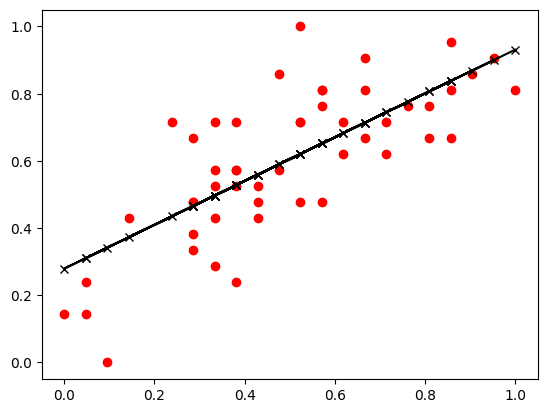

In [11]:
y_pred = model(x_train)
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

# Exercícios

- 1) Calcule o valor da função de custo (MSE) depois da rede treinada, utilizando a
   função `criterion` utilizada no laço de treinamento.

In [12]:
y_pred = model(Variable(x_train))
loss = criterion(y_pred, Variable(y_train))
print(f"MSE Loss after training: {loss.data:.6f}")

MSE Loss after training: 0.021243


In [13]:
#todo

<details>
<summary>Mostrar Resultado</summary>

```python
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(loss)
```

</details>

- 2) Faça igual o exercício do notebook anterior, de plotar um gráfico scatterplot para
   mostrar a evolução dos parâmetros durante o treinamento pelo gradiente descendente.

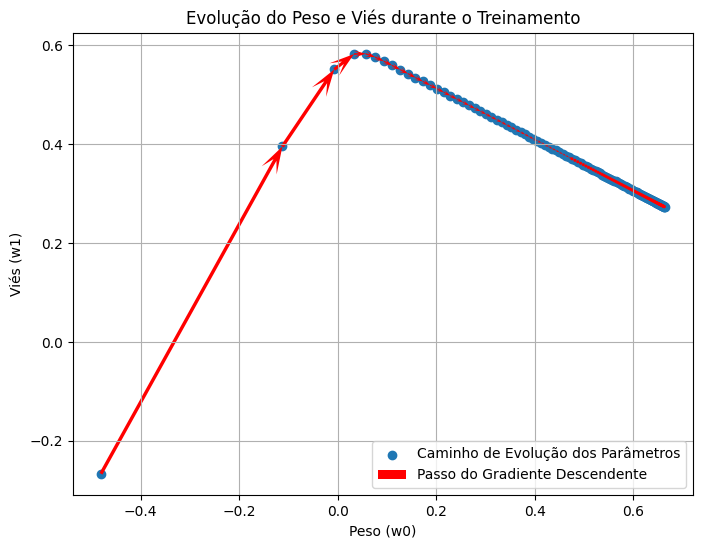

In [14]:
# Re-inicializa um novo modelo para rastrear os parâmetros desde o início
new_model = torch.nn.Linear(1, 1)
new_criterion = nn.MSELoss()
new_optimizer = optim.SGD(new_model.parameters(), lr=0.3)

w0_list = []
w1_list = []

num_epochs = 120 # Usando o mesmo número de épocas do treinamento original

for epoch in range(num_epochs):
    # Armazena o peso e o viés atuais
    w0_list.append(new_model.weight.item())
    w1_list.append(new_model.bias.item())

    # Forward pass
    out = new_model(x_train)
    loss = new_criterion(out, y_train)

    # Backward e otimizador
    new_optimizer.zero_grad()
    loss.backward()
    new_optimizer.step()

plt.figure(figsize=(8, 6))
plt.scatter(w0_list, w1_list, label='Caminho de Evolução dos Parâmetros')

# Plotagem otimizada de setas usando plt.quiver
# Converte listas para arrays numpy para operações vetorizadas
w0_arr = np.array(w0_list)
w1_arr = np.array(w1_list)

# Calcula a mudança em w0 e w1 entre os passos
U = np.diff(w0_arr) # mudança em x
V = np.diff(w1_arr) # mudança em y
X = w0_arr[:-1]     # coordenadas x iniciais
Y = w1_arr[:-1]     # coordenadas y iniciais

# Plota as setas
plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color='red',
           headwidth=5, headlength=8, label='Passo do Gradiente Descendente')

plt.xlabel('Peso (w0)')
plt.ylabel('Viés (w1)')
plt.title('Evolução do Peso e Viés durante o Treinamento')
plt.grid(True)
plt.legend()
plt.show()

<details>
<summary>Mostrar Resultado</summary>

```python
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1
```

</details>

# Aprendizados

## Aprendizados do Notebook e Exercícios

Os principais aprendizados deste notebook e dos exercícios resolvidos incluem:

1.  **Implementação de Regressão Linear com PyTorch**: Entendimento de como construir um modelo de regressão linear simples usando `torch.nn.Linear`.
2.  **Função de Perda MSE**: Aplicação e importância da função de perda `nn.MSELoss` para avaliar a diferença entre as previsões do modelo e os valores reais.
3.  **Otimizador SGD**: Utilização do otimizador `optim.SGD` para ajustar os parâmetros do modelo através do gradiente descendente, minimizando a função de perda.
4.  **Ciclo de Treinamento**: Compreensão do processo iterativo de treinamento, incluindo o *forward pass* (previsão), cálculo da perda, *backward pass* (cálculo de gradientes) e *step* (atualização dos parâmetros).
5.  **Preparação de Dados**: A necessidade e os passos para normalizar os dados de entrada (`x_train`, `y_train`) e convertê-los para tensores PyTorch (`torch.FloatTensor`).
6.  **Visualização da Evolução dos Parâmetros**: A capacidade de rastrear e plotar a evolução dos pesos (`weight`) e vieses (`bias`) do modelo durante o treinamento. Isso permite visualizar o caminho percorrido pelo algoritmo de gradiente descendente no espaço de parâmetros, observando como ele converge para uma solução ideal.
7.  **Cálculo da Perda Pós-Treinamento**: Como calcular e interpretar o valor final da função de custo (MSE) após o treinamento completo do modelo, para quantificar a performance final.
8.  **Importância da Visualização**: A relevância de gráficos (como o scatterplot da evolução dos parâmetros e o gráfico de ajuste da linha) para entender visualmente o comportamento do modelo e o processo de otimização.